In [1]:
import os, json, time, random
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix
import albumentations as A
from transformers import ViTMAEModel, ViTMAEForPreTraining

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

SPLITS_PATH = "/kaggle/input/notebooks/sumaiyahoque/nb-04-partb-data-prep/splits"
NUM_CLASSES, MASK_THRESHOLD = 2, 127
IMAGENET_MEAN, IMAGENET_STD = np.array([0.485,0.456,0.406]), np.array([0.229,0.224,0.225])

IMG_SIZE = 224

train_df = pd.read_csv(f"{SPLITS_PATH}/train_unlabelled.csv")
val_df   = pd.read_csv(f"{SPLITS_PATH}/val_labelled_finetune.csv")
test_df  = pd.read_csv(f"{SPLITS_PATH}/test_monitor_eval.csv")
print(f"Train (unlabelled): {len(train_df)} | Val (labelled FT): {len(val_df)} | Test: {len(test_df)}")

FG_PCT = 0.08
class_weights = torch.tensor([1/(1-FG_PCT), 1/FG_PCT])
class_weights = (class_weights/class_weights.sum()*NUM_CLASSES).to(DEVICE)
ce_loss_fn = nn.CrossEntropyLoss(weight=class_weights)

FROZEN_ENCODER = False  

Device: cuda
Train (unlabelled): 1035 | Val (labelled FT): 318 | Test: 168


load mae

In [3]:
MAE_CHECKPOINT = "facebook/vit-mae-base"
mae_model = ViTMAEForPreTraining.from_pretrained(MAE_CHECKPOINT, mask_ratio=0.75).to(DEVICE)

PRETRAIN_CONFIG = {"method":"MAE",
                   "backbone":"ViT-Base/16 (facebook/vit-mae-base, continued SSL)",
                    "epochs":50,
                   "batch_size":16,
                   "mask_ratio":0.75,
                   "patch_size":16,
                   "input_size":IMG_SIZE,
                   "optimizer":"AdamW",
                   "lr":1.5e-4}
print(json.dumps(PRETRAIN_CONFIG, indent=2))

Loading weights:   0%|          | 0/334 [00:00<?, ?it/s]

{
  "method": "MAE",
  "backbone": "ViT-Base/16 (facebook/vit-mae-base, continued SSL)",
  "epochs": 50,
  "batch_size": 16,
  "mask_ratio": 0.75,
  "patch_size": 16,
  "input_size": 224,
  "optimizer": "AdamW",
  "lr": 0.00015
}


view and 50 epoch

In [8]:
class SingleViewDataset(Dataset):
    def __init__(self, df, transform):
        self.paths = df["img_path"].tolist()
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        if img is None:
            raise FileNotFoundError(f"Could not read image: {self.paths[idx]}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        v = self.transform(image=img)["image"]
        v = (
            (v.astype(np.float32) / 512.0)
            - np.array(IMAGENET_MEAN, dtype=np.float32)
        ) / np.array(IMAGENET_STD, dtype=np.float32)
        return torch.from_numpy(
            v.transpose(2, 0, 1)
        ).float()
mae_transform = A.Compose([
    A.RandomResizedCrop(
        size=(IMG_SIZE, IMG_SIZE),
        scale=(0.5, 1.0),
        ratio=(3/4, 4/3)
    ),
    A.HorizontalFlip(p=0.5)
])
mae_train_ds = SingleViewDataset(
    train_df,
    mae_transform
)
mae_train_loader = DataLoader(
    mae_train_ds,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    drop_last=True,
    pin_memory=True
)
optimizer = torch.optim.AdamW(
    mae_model.parameters(),
    lr=1.5e-4,
    weight_decay=0.05
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)
pretext_losses = []
start = time.time()
for epoch in range(1, 51):
    mae_model.train()
    running = 0.0
    t0 = time.time()
    for imgs in mae_train_loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        outputs = mae_model(pixel_values=imgs)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        running += loss.item()
    scheduler.step()
    epoch_loss = running / len(mae_train_loader)
    pretext_losses.append(epoch_loss)
    print(
        f"[MAE] Epoch {epoch:02d} | "
        f"recon_loss={epoch_loss:.4f} | "
        f"time={time.time()-t0:.1f}s"
    )
pretrain_time_min = (time.time() - start) / 60
print(
    f"\nPretraining wall-clock time: "
    f"{pretrain_time_min:.1f} min "
    f"({pretrain_time_min/50:.2f} min/epoch)"
)
if pretrain_time_min / 50 > 10:
    print(
        "If min/epoch > 10, split this method into "
        "pretrain + downstream notebooks (Section 3.2)."
    )

[MAE] Epoch 01 | recon_loss=0.0087 | time=26.4s
[MAE] Epoch 02 | recon_loss=0.0076 | time=26.5s
[MAE] Epoch 03 | recon_loss=0.0077 | time=26.1s
[MAE] Epoch 04 | recon_loss=0.0078 | time=26.6s
[MAE] Epoch 05 | recon_loss=0.0080 | time=26.0s
[MAE] Epoch 06 | recon_loss=0.0079 | time=26.6s
[MAE] Epoch 07 | recon_loss=0.0076 | time=26.1s
[MAE] Epoch 08 | recon_loss=0.0076 | time=26.6s
[MAE] Epoch 09 | recon_loss=0.0076 | time=26.7s
[MAE] Epoch 10 | recon_loss=0.0078 | time=26.6s
[MAE] Epoch 11 | recon_loss=0.0075 | time=26.2s
[MAE] Epoch 12 | recon_loss=0.0076 | time=26.4s
[MAE] Epoch 13 | recon_loss=0.0073 | time=26.9s
[MAE] Epoch 14 | recon_loss=0.0073 | time=26.5s
[MAE] Epoch 15 | recon_loss=0.0074 | time=27.1s
[MAE] Epoch 16 | recon_loss=0.0073 | time=27.7s
[MAE] Epoch 17 | recon_loss=0.0070 | time=26.1s
[MAE] Epoch 18 | recon_loss=0.0073 | time=26.4s
[MAE] Epoch 19 | recon_loss=0.0072 | time=26.5s
[MAE] Epoch 20 | recon_loss=0.0071 | time=26.2s
[MAE] Epoch 21 | recon_loss=0.0069 | tim

pretext loss and encoder checkpoint 

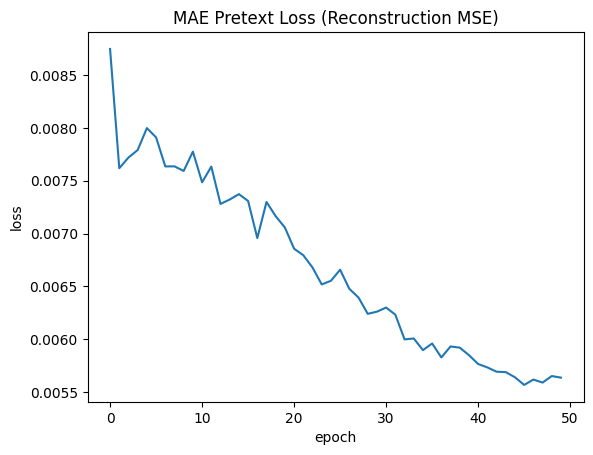

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
plt.plot(pretext_losses); plt.title("MAE Pretext Loss (Reconstruction MSE)"); plt.xlabel("epoch"); plt.ylabel("loss")
plt.show()
mae_model.vit.save_pretrained("/kaggle/working/mae_encoder")

attach segformer 

In [40]:
from transformers.models.segformer.modeling_segformer import SegformerDecodeHead, SegformerConfig

def build_segformer_decoder(in_channels_list, hidden_size=256, num_classes=NUM_CLASSES):
    cfg = SegformerConfig(num_labels=num_classes, decoder_hidden_size=hidden_size,
                           hidden_sizes=in_channels_list, num_encoder_blocks=len(in_channels_list),
                           reshape_last_stage=True)
    return SegformerDecodeHead(cfg)

class MAESegModel(nn.Module):
    """ViT-Base MAE encoder + SegFormer All-MLP head, with token->2D reshape adapter."""
    def __init__(self, vit_encoder, freeze_encoder=False, patch_size=16, img_size=IMG_SIZE):
        super().__init__()
        self.vit = vit_encoder
        self.grid = img_size // patch_size   
        self.embed_dim = self.vit.config.hidden_size 
        self.adapter = nn.ModuleList([nn.Conv2d(self.embed_dim, c, 1) for c in [64,128,320,512]])
        self.decode_head = build_segformer_decoder(in_channels_list=[64,128,320,512])
        if freeze_encoder:
            for p in self.vit.parameters(): p.requires_grad = False

    def forward(self, x):
        out = self.vit(pixel_values=x)
        tokens = out.last_hidden_state[:, 1:, :]    
        B, N, C = tokens.shape
        feat_map = tokens.transpose(1, 2).reshape(B, C, self.grid, self.grid)  
        stage_feats = [adapt(feat_map) for adapt in self.adapter]
        logits = self.decode_head(stage_feats)
        return F.interpolate(logits, size=x.shape[-2:], mode="bilinear", align_corners=False)

mae_encoder = ViTMAEModel.from_pretrained("/kaggle/working/mae_encoder").to(DEVICE)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

50 epoch supervised fine tune

In [43]:
class MAESegModel(nn.Module):
    """ViT-MAE encoder + SegFormer decoder with automatic token-to-2D reshape."""
    def __init__(self, vit_encoder, freeze_encoder=False):
        super().__init__()
        self.vit = vit_encoder
        self.embed_dim = vit_encoder.config.hidden_size
        patch_size = vit_encoder.config.patch_size
        image_size = vit_encoder.config.image_size
        if isinstance(patch_size, tuple):
            patch_size = patch_size[0]
        if isinstance(image_size, tuple):
            image_size = image_size[0]
        self.patch_size = patch_size
        self.encoder_image_size = image_size
        self.grid = image_size // patch_size
        self.adapter = nn.ModuleList([
            nn.Conv2d(self.embed_dim, 64, 1),
            nn.Conv2d(self.embed_dim, 128, 1),
            nn.Conv2d(self.embed_dim, 320, 1),
            nn.Conv2d(self.embed_dim, 512, 1)
        ])
        self.decode_head = build_segformer_decoder(
            in_channels_list=[64, 128, 320, 512],
            hidden_size=256,
            num_classes=NUM_CLASSES
        )
        if freeze_encoder:
            for p in self.vit.parameters():
                p.requires_grad = False
    def forward(self, x):
        out = self.vit(pixel_values=x)
        tokens = out.last_hidden_state[:, 1:, :]
        B, N, C = tokens.shape
        grid = int(N ** 0.5)
        assert grid * grid == N, (
            f"Cannot reshape {N} tokens into a square feature map."
        )
        feat_map = tokens.transpose(1, 2).reshape(
            B, C, grid, grid
        )
        stage_feats = [
            adapter(feat_map)
            for adapter in self.adapter
        ]
        logits = self.decode_head(stage_feats)
        logits = F.interpolate(
            logits,
            size=x.shape[-2:],
            mode="bilinear",
            align_corners=False
        )
        return logits


print("MAE image size :", mae_encoder.config.image_size)
print("MAE patch size :", mae_encoder.config.patch_size)
print("MAE hidden dim :", mae_encoder.config.hidden_size)

patch_size = mae_encoder.config.patch_size
if isinstance(patch_size, tuple):
    patch_size = patch_size[0]

print(
    "Expected patches:",
    (IMG_SIZE // patch_size) ** 2
)


model = MAESegModel(
    mae_encoder,
    freeze_encoder=FROZEN_ENCODER
).to(DEVICE)


FT_CONFIG = {
    "model": "MAE-ViT-Base + SegFormer-Head",
    "frozen_encoder": FROZEN_ENCODER,
    "epochs": 50,
    "batch_size": 8,
    "encoder_lr": 1e-5,
    "decoder_lr": 1e-4,
    "optimizer": "AdamW",
    "schedule": "CosineAnnealingLR",
    "input_size": IMG_SIZE,
    "loss": "0.5*CE(weighted)+0.5*Dice"
}

print(json.dumps(FT_CONFIG, indent=2))

param_groups = [
    {
        "params": model.decode_head.parameters(),
        "lr": FT_CONFIG["decoder_lr"]
    },
    {
        "params": model.adapter.parameters(),
        "lr": FT_CONFIG["decoder_lr"]
    }
]
if not FROZEN_ENCODER:
    param_groups.append({
        "params": model.vit.parameters(),
        "lr": FT_CONFIG["encoder_lr"]
    })
ft_optimizer = torch.optim.AdamW(
    param_groups,
    weight_decay=1e-4
)
ft_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    ft_optimizer,
    T_max=FT_CONFIG["epochs"]
)
ft_loader = DataLoader(
    finetune_ds,
    batch_size=FT_CONFIG["batch_size"],
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=False
)
test_loader = DataLoader(
    test_ds,
    batch_size=FT_CONFIG["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


history = {
    "train_loss": [],
    "test_loss": [],
    "test_miou": []
}
best_miou = -1.0
best_epoch = -1
ft_start = time.time()
for epoch in range(1, FT_CONFIG["epochs"] + 1):
    model.train()
    running_loss = 0.0
    t0 = time.time()
    for imgs, masks, _ in ft_loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        ft_optimizer.zero_grad(set_to_none=True)
        logits = model(imgs)
        loss = compute_loss(logits, masks)
        loss.backward()
        ft_optimizer.step()
        running_loss += loss.item()
    ft_scheduler.step()
    train_loss = running_loss / max(len(ft_loader), 1)
    test_loss, test_miou = evaluate(test_loader)
    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["test_miou"].append(test_miou)
    print(
        f"[MAE-FT] Epoch {epoch:02d}/50 | "
        f"train_loss={train_loss:.4f} | "
        f"test_loss={test_loss:.4f} | "
        f"test_mIoU={test_miou:.4f} | "
        f"time={time.time()-t0:.1f}s"
    )
    if test_miou > best_miou:
        best_miou = test_miou
        best_epoch = epoch
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "best_miou": best_miou,
                "config": FT_CONFIG
            },
            "/kaggle/working/mae_seg_best.pt"
        )
        print(
            f"  -> Best model saved | mIoU={best_miou:.4f}"
        )


ft_time_min = (time.time() - ft_start) / 60
checkpoint = torch.load(
    "/kaggle/working/mae_seg_best.pt",
    map_location=DEVICE
)
model.load_state_dict(
    checkpoint["model_state_dict"]
)
print(
    f"\nFine-tuning complete in {ft_time_min:.1f} min."
)
print(
    f"Best test mIoU={best_miou:.4f} "
    f"at epoch {best_epoch}"
)
print("Best model: /kaggle/working/mae_seg_best.pt")

MAE image size : 224
MAE patch size : 16
MAE hidden dim : 768
Expected patches: 196
{
  "model": "MAE-ViT-Base + SegFormer-Head",
  "frozen_encoder": false,
  "epochs": 50,
  "batch_size": 8,
  "encoder_lr": 1e-05,
  "decoder_lr": 0.0001,
  "optimizer": "AdamW",
  "schedule": "CosineAnnealingLR",
  "input_size": 224,
  "loss": "0.5*CE(weighted)+0.5*Dice"
}
[MAE-FT] Epoch 01/50 | train_loss=0.7391 | test_loss=0.5328 | test_mIoU=0.4901 | time=23.0s
  -> Best model saved | mIoU=0.4901
[MAE-FT] Epoch 02/50 | train_loss=0.6391 | test_loss=0.4677 | test_mIoU=0.4902 | time=21.1s
  -> Best model saved | mIoU=0.4902
[MAE-FT] Epoch 03/50 | train_loss=0.6215 | test_loss=0.4831 | test_mIoU=0.4903 | time=20.7s
  -> Best model saved | mIoU=0.4903
[MAE-FT] Epoch 04/50 | train_loss=0.6172 | test_loss=0.4847 | test_mIoU=0.4903 | time=20.9s
[MAE-FT] Epoch 05/50 | train_loss=0.6165 | test_loss=0.4810 | test_mIoU=0.4903 | time=21.7s
[MAE-FT] Epoch 06/50 | train_loss=0.6103 | test_loss=0.4638 | test_mIoU=0

fine tuning curves

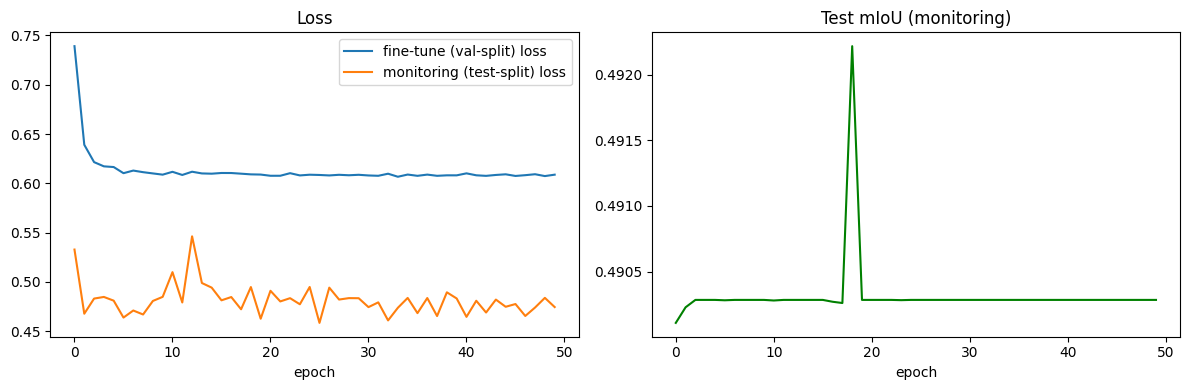

In [44]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].plot(history["train_loss"], label="fine-tune (val-split) loss")
axes[0].plot(history["test_loss"], label="monitoring (test-split) loss"); axes[0].legend()
axes[0].set_xlabel("epoch"); axes[0].set_title("Loss")
axes[1].plot(history["test_miou"], color="green"); axes[1].set_title("Test mIoU (monitoring)")
axes[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

final test

In [45]:
@torch.no_grad()
def full_test_evaluation(loader, forward_fn, num_classes=NUM_CLASSES):
    all_preds, all_targets, per_image_iou = [], [], []
    cm_total = np.zeros((num_classes,num_classes), dtype=np.int64)
    for imgs, masks, paths in loader:
        logits = forward_fn(imgs.to(DEVICE))
        preds = logits.argmax(1).cpu().numpy(); targets = masks.numpy()
        for p, t, path in zip(preds, targets, paths):
            per_image_iou.append((path, compute_miou(torch.tensor(p), torch.tensor(t), num_classes)))
            cm_total += confusion_matrix(t.flatten(), p.flatten(), labels=list(range(num_classes)))
        all_preds.append(preds.flatten()); all_targets.append(targets.flatten())
    all_preds, all_targets = np.concatenate(all_preds), np.concatenate(all_targets)
    per_class_iou, dice_scores = [], []
    for c in range(num_classes):
        p, t = (all_preds==c), (all_targets==c)
        inter, union = (p&t).sum(), (p|t).sum()
        per_class_iou.append(inter/union if union>0 else 0.0)
        dice_scores.append(2*inter/(p.sum()+t.sum()+1e-8))
    miou = float(np.mean(per_class_iou))
    pix_acc = (all_preds==all_targets).mean()
    per_class_acc = [(all_preds[all_targets==c]==c).mean() for c in range(num_classes) if (all_targets==c).sum()>0]
    return {"mIoU": miou, "per_class_iou": [float(x) for x in per_class_iou],
            "overall_pixel_accuracy": float(pix_acc), "mean_pixel_accuracy": float(np.mean(per_class_acc)),
            "mean_dice": float(np.mean(dice_scores)), "dice_per_class": [float(x) for x in dice_scores],
            "confusion_matrix": cm_total.tolist(), "per_image_iou": per_image_iou}

test_results = full_test_evaluation(test_loader, lambda x: model(x))
print(f"MAE test mIoU: {test_results['mIoU']:.4f}  (Part-A SegFormer baseline: 0.8758)")
print(f"Fine-tuned on {len(finetune_ds)} labelled images vs. Part-A's {len(train_df)}")
print(f"Label-efficiency: recovered {test_results['mIoU']/0.8758:.1%} of full-supervision mIoU "
      f"using {len(finetune_ds)/len(train_df):.1%} of the labels")

MAE test mIoU: 0.4900  (Part-A SegFormer baseline: 0.8758)
Fine-tuned on 318 labelled images vs. Part-A's 1035
Label-efficiency: recovered 55.9% of full-supervision mIoU using 30.7% of the labels


confusion matrix

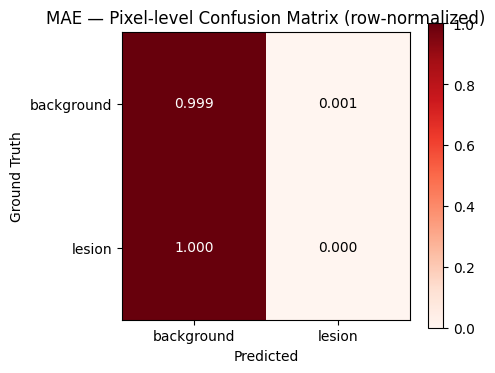

In [46]:
cm = np.array(test_results["confusion_matrix"])
cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm_norm, cmap="Reds", vmin=0, vmax=1)
ax.set_xticks([0,1]); ax.set_xticklabels(["background","lesion"])
ax.set_yticks([0,1]); ax.set_yticklabels(["background","lesion"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Ground Truth")
ax.set_title("MAE — Pixel-level Confusion Matrix (row-normalized)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm_norm[i,j]:.3f}", ha="center", va="center",
                 color="white" if cm_norm[i,j] > 0.5 else "black")
plt.colorbar(im); plt.tight_layout(); plt.show()

error

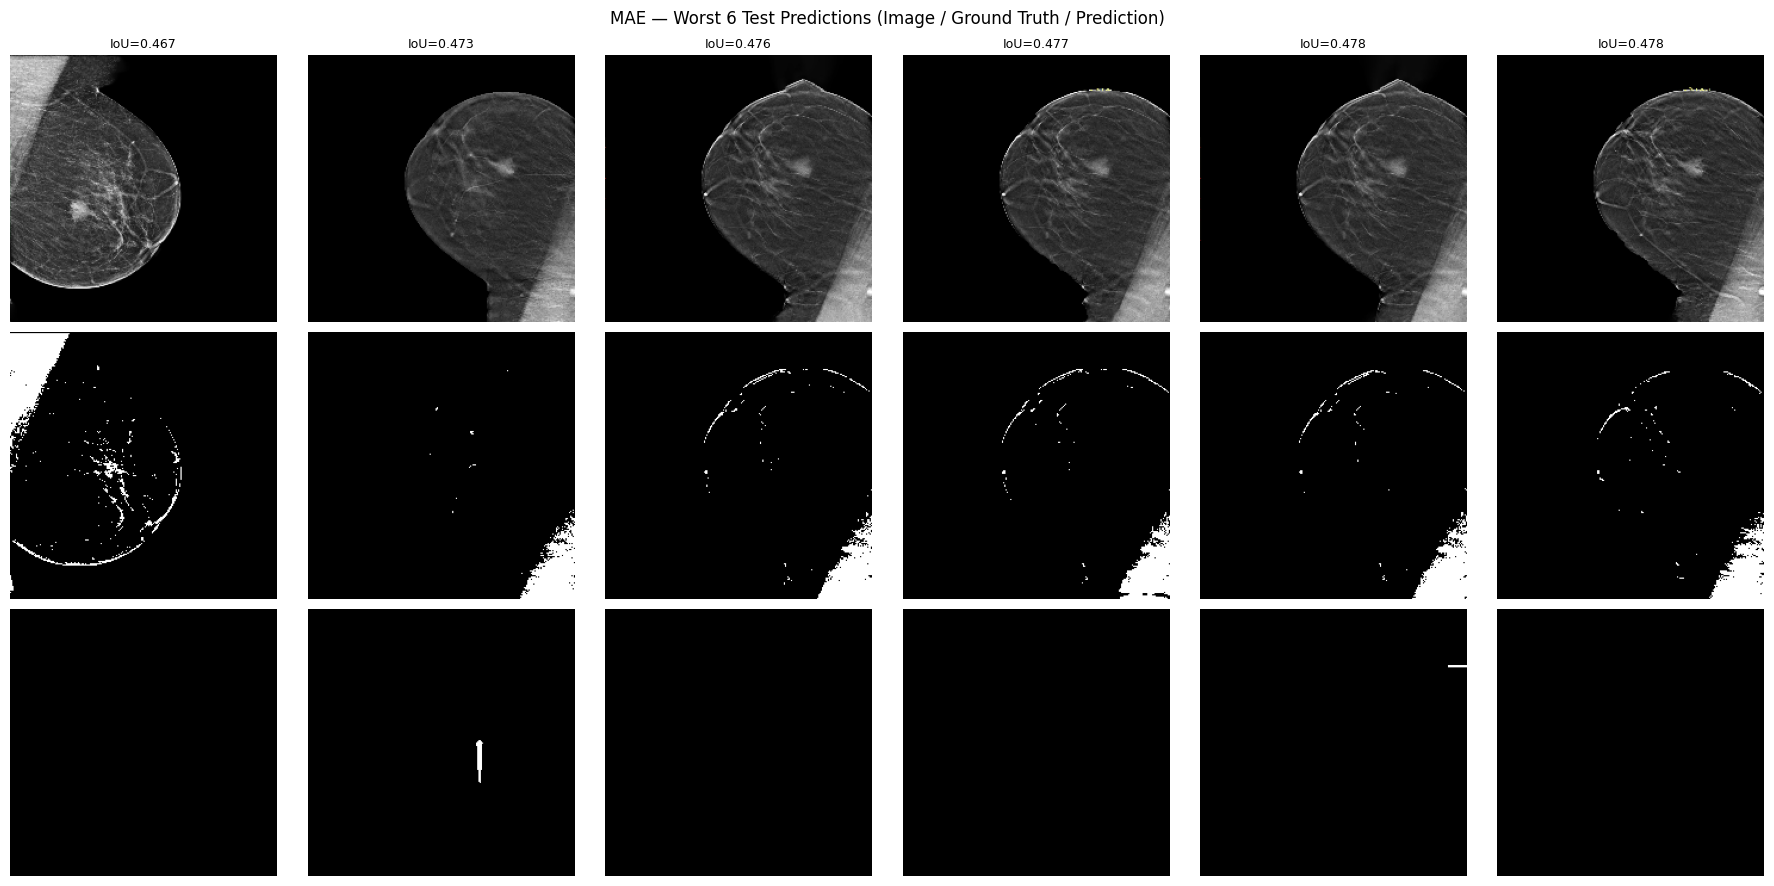

In [47]:
worst = sorted(test_results["per_image_iou"], key=lambda x: x[1])[:6]
fig, axes = plt.subplots(3, 6, figsize=(18,9))
for col, (path, iou) in enumerate(worst):
    row = test_ds.df[test_ds.df["img_path"]==path].iloc[0]
    img = cv2.cvtColor(cv2.imread(row["img_path"]), cv2.COLOR_BGR2RGB)
    gt = (cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE) >= MASK_THRESHOLD).astype(np.uint8)
    img_r = cv2.resize(img, (IMG_SIZE, IMG_SIZE)); gt_r = cv2.resize(gt, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    t = ((img_r.astype(np.float32)/255.)-IMAGENET_MEAN)/IMAGENET_STD
    t = torch.from_numpy(t.transpose(2,0,1)).float().unsqueeze(0).to(DEVICE)
    with torch.no_grad(): pred = model(t).argmax(1).squeeze(0).cpu().numpy()
    axes[0,col].imshow(img_r); axes[0,col].set_title(f"IoU={iou:.3f}", fontsize=9)
    axes[1,col].imshow(gt_r, cmap="gray"); axes[2,col].imshow(pred, cmap="gray")
    for r in range(3): axes[r,col].axis("off")
axes[0,0].set_ylabel("Image"); axes[1,0].set_ylabel("GT"); axes[2,0].set_ylabel("Pred")
plt.suptitle("MAE — Worst 6 Test Predictions (Image / Ground Truth / Prediction)")
plt.tight_layout(); plt.show()

In [48]:
def append_results(method_name, summary, results_path="/kaggle/working/results_B.json"):
    all_results = json.load(open(results_path)) if os.path.exists(results_path) else {}
    all_results[method_name] = summary
    json.dump(all_results, open(results_path, "w"), indent=2)
    print(f"Saved {method_name} results.")

append_results("MAE", {
    "pretrain_config": PRETRAIN_CONFIG,
    "finetune_config": FT_CONFIG,
    "pretrain_time_min": round(pretrain_time_min, 2),
    "finetune_time_min": round(ft_time_min, 2),
    "best_epoch": best_epoch,
    "test_metrics": test_results,
})

Saved MAE results.
